In [45]:
%matplotlib inline

from __future__ import division

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.simplefilter("ignore", pd.errors.SettingWithCopyWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*log10")

In [46]:
filename = "../3BodyProblem/I_239_selection.tsv"
df = pd.read_table(filename, skiprows=44, sep=';', header=None, index_col=0,
                   names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType'],
                   skipfooter=1, engine='python')

In [47]:
df.head()

,Vmag,Plx,B-V,SpType
HIP,,,,
10,8.59,10.76,0.489,F6V
11,7.34,4.29,0.081,A2
12,8.43,4.06,1.484,K4III
13,8.80,3.49,1.128,K0III
14,7.25,5.11,1.200,K0


In [48]:
df.tail()

,Vmag,Plx,B-V,SpType
HIP,,,,
118318,6.99,1.92,1.595,K2
118319,8.23,10.63,0.639,G2V
118320,7.59,5.00,0.999,K0
118321,9.20,19.22,0.698,G5V
118322,4.49,8.71,-0.075,B9IV


In [49]:
df.describe()

,Vmag,Plx,B-V,SpType
count,118209,118209,118209,115175
unique,1127,5617,2437,4123
top,8.69,,,K0
freq,504,263,1281,8570


In [50]:
df_clean = df.map(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

In [51]:
df_clean.describe()

,Vmag,Plx,B-V,SpType
count,118208,117946,116928,115175
unique,1126,5616,2436,4123
top,8.69,2.93,1.000,K0
freq,504,183,317,8570


In [52]:
df_clean= df_clean.dropna()
df_clean.describe()

,Vmag,Plx,B-V,SpType
count,114463,114463,114463,114463
unique,1072,5361,2426,4069
top,8.69,2.93,1.000,K0
freq,502,182,308,8537


In [53]:
df_clean.shape

(114463, 4)

In [54]:
df_clean['Vmag'] = df_clean['Vmag'].astype(np.float64)
df_clean['Plx'] = df_clean['Plx'].astype(np.float64)
df_clean['B-V'] = df_clean['B-V'].astype(np.float64)

In [55]:
df_clean['M_V'] = df_clean['Vmag'] + 5 * np.log10(df_clean['Plx']/100.)

In [56]:
df_clean.head()

,Vmag,Plx,B-V,SpType,M_V
HIP,,,,,
10,8.59,10.76,0.489,F6V,3.749061
11,7.34,4.29,0.081,A2,0.502286
12,8.43,4.06,1.484,K4III,1.472630
13,8.80,3.49,1.128,K0III,1.514127
14,7.25,5.11,1.200,K0,0.792105


In [57]:
f = lambda s: (len(s) >= 2)  and (s[0].isalpha()) and (s[1].isdigit())
i  = df_clean['SpType'].apply(f)
df_clean = df_clean[i]

f = lambda s: s[0:2]
df_clean['SpType2'] = df_clean['SpType'].apply(f)

In [58]:
df_clean.shape

(111553, 6)

In [59]:
df_clean.head()

,Vmag,Plx,B-V,SpType,M_V,SpType2
HIP,,,,,,
10,8.59,10.76,0.489,F6V,3.749061,F6
11,7.34,4.29,0.081,A2,0.502286,A2
12,8.43,4.06,1.484,K4III,1.472630,K4
13,8.80,3.49,1.128,K0III,1.514127,K0
14,7.25,5.11,1.200,K0,0.792105,K0


In [60]:
f = lambda s: s[0]
classes = df_clean['SpType'].map(f)
classes.value_counts()

SpType
K    31577
F    25199
G    22210
A    17651
B    10280
M     4210
O      256
C       82
N       48
R       23
S       17
Name: count, dtype: int64

In [61]:
f = lambda s: s[0] in 'OBAFGKM'
df_clean = df_clean[df_clean['SpType'].map(f)]

In [62]:
f = lambda s: s[0]
classes = df_clean['SpType'].map(f)
classes.value_counts()

SpType
K    31577
F    25199
G    22210
A    17651
B    10280
M     4210
O      256
Name: count, dtype: int64

In [63]:
order = {'O':'0', 'B':'1', 'A':'2', 'F':'3', 'G':'4', 'K':'5', 'M':'6'}
f = lambda s: order[s[0]]+s[1]
df_clean['SpType2'] = df_clean['SpType2'].apply(f)
df_clean.head()

,Vmag,Plx,B-V,SpType,M_V,SpType2
HIP,,,,,,
10,8.59,10.76,0.489,F6V,3.749061,36
11,7.34,4.29,0.081,A2,0.502286,22
12,8.43,4.06,1.484,K4III,1.472630,54
13,8.80,3.49,1.128,K0III,1.514127,50
14,7.25,5.11,1.200,K0,0.792105,50


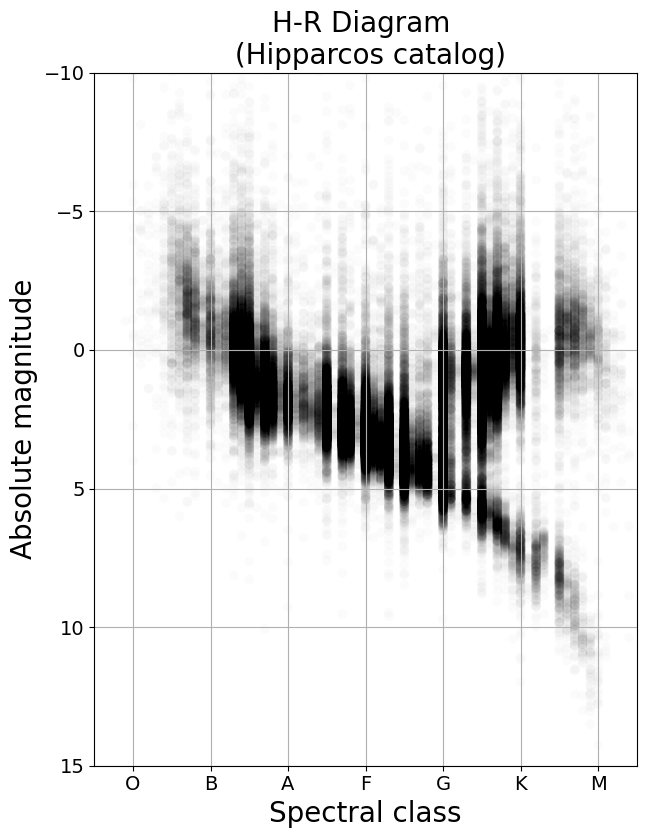

In [68]:
fig, ax = plt.subplots(figsize=(7,9))

ax.set_xlim(0, 70)
ax.set_ylim(15, -10)
ax.grid()
ax.set_title('H-R Diagram \n (Hipparcos catalog)')

ax.title.set_fontsize(20)
ax.set_xlabel('Spectral class')
ax.xaxis.label.set_fontsize(20)
ax.set_ylabel('Absolute magnitude')
ax.yaxis.label.set_fontsize(20)

ax.scatter(df_clean['SpType2'].astype(int), df_clean['M_V'],
           s=50, edgecolors='none', alpha=0.015, c='k')
ax.set_xticks(range(5,75,10))
ax.set_xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])
ax.tick_params(axis='both', labelsize=14)

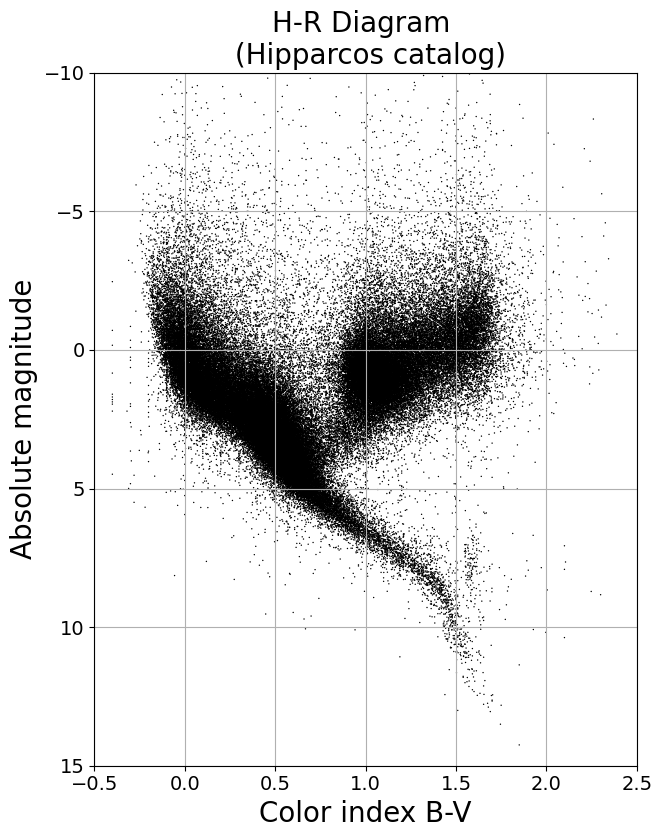

In [67]:
fig, ax = plt.subplots(figsize=(7,9))

ax.set_xlim(-0.5, 2.5)
ax.set_ylim(15, -10)
ax.grid()
ax.set_title('H-R Diagram \n (Hipparcos catalog)')

ax.title.set_fontsize(20)
ax.set_xlabel('Color index B-V')
ax.xaxis.label.set_fontsize(20)
ax.set_ylabel('Absolute magnitude')
ax.yaxis.label.set_fontsize(20)

ax.scatter(df_clean['B-V'], df_clean['M_V'],
           s=1, edgecolors='none', c='k')

ax.tick_params(axis='both', labelsize=14)